# 🏋️ Egzersiz Öneri Sistemi

**Proje:** Kas grubuna göre kişiselleştirilmiş antrenman programı oluşturucu  
**Yöntem:** İçerik Tabanlı Filtreleme — TF-IDF + Cosine Similarity  
**Veri Seti:** The Ultimate Gym Exercises Dataset for All Levels (Kaggle)

---

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Kütüphaneler başarıyla yüklendi.")

✅ Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme

In [2]:
# Veri setini yükle (Workout.csv olarak gelir Kaggle'dan)
df = pd.read_csv('Workout.csv')

print(f"Veri seti boyutu: {df.shape}")
print(f"Sütunlar: {df.columns.tolist()}")
print()
df.head(10)

Veri seti boyutu: (52, 5)
Sütunlar: ['Body Part', 'Type of Muscle', 'Workout', 'Sets', 'Reps per Set']



,Body Part,Type of Muscle,Workout,Sets,Reps per Set
0,Chest,Upper Chest,Incline dumbbell press,3-4,8-12
1,Chest,Upper Chest,Incline cable crossovers,3-4,10-15
2,Chest,Upper Chest,Incline dumbbell flyes,3-4,10-15
3,Chest,Lower Chest,Decline dumbbell press,3-4,8-12
4,Chest,Lower Chest,Decline cable crossovers,3-4,10-15
5,Chest,Lower Chest,Decline dumbbell flyes,3-4,10-15
6,Chest,Chest Isolation,Chest flyes,3-4,10-15
7,Chest,Chest Isolation,Cable crossovers,3-4,10-15
8,Chest,Chest Isolation,Dumbbell flyes,3-4,10-15
9,Back,Upper,Pull-ups,3-4,8-12


## 3. Keşifsel Veri Analizi (EDA)

In [3]:
# Eksik veri kontrolü
print("=== EKSİK VERİ ===")
print(df.isnull().sum())

print("\n=== BODY PART DAĞILIMI ===")
print(df['Body Part'].value_counts())

print("\n=== TYPE OF MUSCLE DAĞILIMI ===")
print(df['Type of Muscle'].value_counts())

=== EKSİK VERİ ===
Body Part         0
Type of Muscle    0
Workout           0
Sets              0
Reps per Set      0
dtype: int64

=== BODY PART DAĞILIMI ===
Body Part
Arms         10
Chest         9
Legs          9
Back          7
Abs           6
Forearms      6
Shoulders     5
Name: count, dtype: int64

=== TYPE OF MUSCLE DAĞILIMI ===
Type of Muscle
Upper              6
Lower              5
Biceps             5
Triceps            5
Grip Strength      4
Upper Chest        3
Lower Chest        3
Chest Isolation    3
Quadriceps         3
Hamstrings         2
Glutes             2
Calves             2
Anterior           2
Posterior          2
Middle             2
Lateral            1
Wrist Flexors      1
Wrist Extensors    1
Name: count, dtype: int64


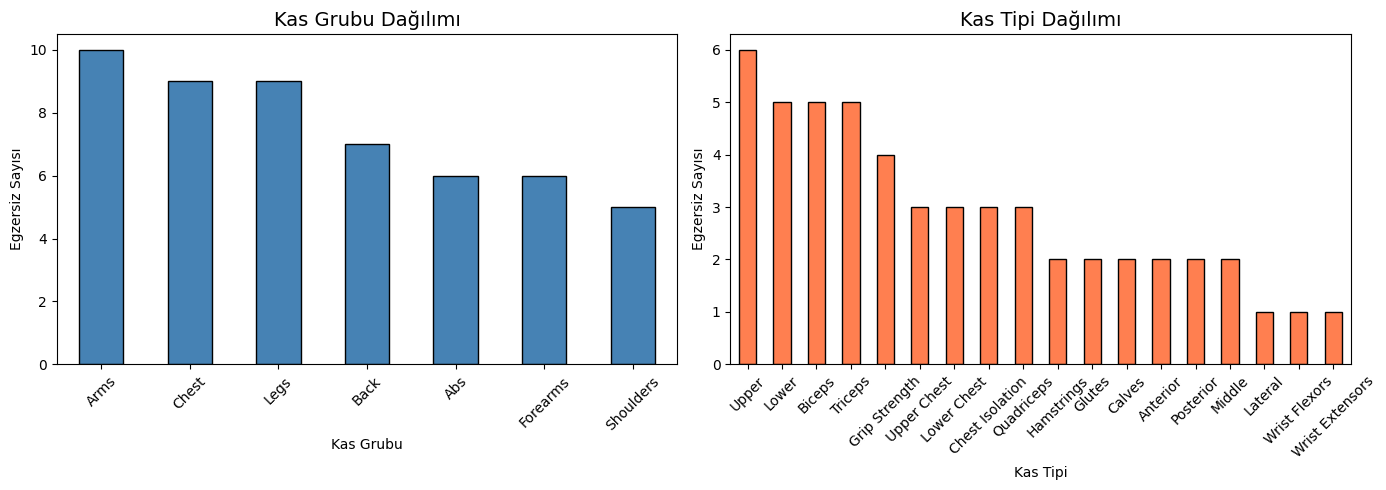

✅ Grafik kaydedildi: eda_grafik.png


In [4]:
# Görselleştirme — iki grafik yan yana
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Body Part'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Kas Grubu Dağılımı', fontsize=14)
axes[0].set_xlabel('Kas Grubu')
axes[0].set_ylabel('Egzersiz Sayısı')
axes[0].tick_params(axis='x', rotation=45)

df['Type of Muscle'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Kas Tipi Dağılımı', fontsize=14)
axes[1].set_xlabel('Kas Tipi')
axes[1].set_ylabel('Egzersiz Sayısı')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_grafik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: eda_grafik.png")

## 4. Özellik Mühendisliği (Feature Engineering)

In [5]:
# Üç sütunu birleştirip tek metin özelliği oluştur
df['text_feature'] = (
    df['Body Part'].fillna('') + ' ' +
    df['Type of Muscle'].fillna('') + ' ' +
    df['Workout'].fillna('')
).str.lower().str.strip()

print("✅ text_feature sütunu oluşturuldu.")
df[['Workout', 'Body Part', 'Type of Muscle', 'text_feature']].head(8)

✅ text_feature sütunu oluşturuldu.


,Workout,Body Part,Type of Muscle,text_feature
0,Incline dumbbell press,Chest,Upper Chest,chest upper chest incline dumbbell press
1,Incline cable crossovers,Chest,Upper Chest,chest upper chest incline cable crossovers
2,Incline dumbbell flyes,Chest,Upper Chest,chest upper chest incline dumbbell flyes
3,Decline dumbbell press,Chest,Lower Chest,chest lower chest decline dumbbell press
4,Decline cable crossovers,Chest,Lower Chest,chest lower chest decline cable crossovers
5,Decline dumbbell flyes,Chest,Lower Chest,chest lower chest decline dumbbell flyes
6,Chest flyes,Chest,Chest Isolation,chest chest isolation chest flyes
7,Cable crossovers,Chest,Chest Isolation,chest chest isolation cable crossovers


## 5. TF-IDF Modeli

TF-IDF (Term Frequency - Inverse Document Frequency) her kelimenin önemini ölçer.  
Cosine Similarity ile egzersizler arasındaki benzerliği hesaplarız —  
bunu kullanarak **birbirine benzemeyen (çeşitli)** hareketleri seçebiliriz.

In [6]:
# Tüm veri seti için TF-IDF matrisi oluştur
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['text_feature'])

print(f"TF-IDF matris boyutu: {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} egzersiz")
print(f"  → {tfidf_matrix.shape[1]} benzersiz kelime özelliği")
print("\n✅ TF-IDF modeli hazır!")

TF-IDF matris boyutu: (52, 78)
  → 52 egzersiz
  → 78 benzersiz kelime özelliği

✅ TF-IDF modeli hazır!


## 6. Öneri Fonksiyonu

Fonksiyon üç adım uygular:
1. Seçilen kas grubuna göre veri setini **filtrele**
2. TF-IDF + **Greedy Max Diversity** ile en çeşitli egzersizleri seç
3. Seçilen egzersizleri günlere **dengeli dağıt**

In [ ]:
def egzersiz_programi_olustur(hedef_kas_grubu, gun_sayisi, gun_basi_egzersiz=3):
    """
    Kullanıcının hedef kas grubuna göre haftalık antrenman programı oluşturur.

    Parametreler:
        hedef_kas_grubu (str) : Veri setindeki Body Part değerlerinden biri
        gun_sayisi      (int) : Kaç günlük program isteniyor (1-6)
        gun_basi_egzersiz(int): Her günde kaç egzersiz olacak (default: 3)

    Döndürür:
        pd.DataFrame: Günlük antrenman programı tablosu
    """

    # Adım 1: Hedef kas grubuna göre filtreleme 
    filtreli_df = df[
        df['Body Part'].str.lower() == hedef_kas_grubu.lower()
    ].copy().reset_index(drop=True)

    if len(filtreli_df) == 0:
        print(f"❌ '{hedef_kas_grubu}' için egzersiz bulunamadı.")
        print(f"   Mevcut kas grupları: {df['Body Part'].unique().tolist()}")
        return None

    toplam_ihtiyac = gun_sayisi * gun_basi_egzersiz
    print(f"  ✔ '{hedef_kas_grubu}' için {len(filtreli_df)} egzersiz bulundu. "
          f"{toplam_ihtiyac} tanesi seçilecek.")

    # Adım 2: Greedy Max Diversity ile egzersiz seçimi 
    tfidf_local        = TfidfVectorizer(stop_words='english')
    tfidf_local_matrix = tfidf_local.fit_transform(filtreli_df['text_feature'])
    cosine_sim         = cosine_similarity(tfidf_local_matrix)

    secilen = [0]   # İlk egzersizle başlangıç

    while len(secilen) < min(toplam_ihtiyac, len(filtreli_df)):
        best_idx, max_min_dist = -1, -1

        for i in range(len(filtreli_df)):
            if i in secilen:
                continue
            # Bu adayın seçilenlere minimum benzerliği
            min_sim = min(cosine_sim[i][j] for j in secilen)
            if min_sim > max_min_dist:
                max_min_dist, best_idx = min_sim, i

        if best_idx == -1:
            break
        secilen.append(best_idx)

    # Yeterli egzersiz yoksa döngüsel tekrarla
    while len(secilen) < toplam_ihtiyac:
        secilen += secilen[:toplam_ihtiyac - len(secilen)]

    secilen_egzersizler = filtreli_df.iloc[secilen[:toplam_ihtiyac]]

    # Adım 3: Günlere dağıt
    rows = []
    for gun in range(gun_sayisi):
        gun_dilim = secilen_egzersizler.iloc[
            gun * gun_basi_egzersiz : (gun + 1) * gun_basi_egzersiz
        ]
        for _, r in gun_dilim.iterrows():
            rows.append({
                'Gün'      : f'Gün {gun + 1}',
                'Hareket'  : r['Workout'],
                'Kas Grubu': r['Body Part'],
                'Kas Tipi' : r['Type of Muscle'],
                'Set'      : r['Sets'],
                'Tekrar'   : r['Reps per Set']
            })

    return pd.DataFrame(rows)

print("✅ Öneri fonksiyonu tanımlandı.")

✅ Öneri fonksiyonu tanımlandı.


## 7. Program Oluştur

Aşağıdaki hücrede `hedef` ve `gun` değişkenlerini değiştirerek kendi programını oluşturabilirsin.  
İstersen `input()` satırlarını yorum satırına alıp doğrudan değer atayabilirsin.

In [11]:
# Mevcut kas gruplarını listele
print("=== MEVCUT KAS GRUPLARI ===")
for i, kg in enumerate(df['Body Part'].unique(), 1):
    print(f"  {i}. {kg}")
print()

# ✏️ Buraya kendi girdilerini yaz (ya da input() ile al)
hedef = input("Hedef kas grubunu girin (örn. Chest): ").strip()
gun   = int(input("Kaç günlük program? (1-6): ").strip())

print("\nProgram oluşturuluyor...\n")
program = egzersiz_programi_olustur(hedef, gun)

if program is not None:
    ayrac = '=' * 55
    print(f"\n{ayrac}")
    print(f"  {hedef.upper()} — {gun} GÜNLÜK ANTRENMAN PROGRAMI")
    print(f"{ayrac}\n")

    for gun_no, grup in program.groupby('Gün', sort=False):
        print(f"📅 {gun_no}")
        print(grup[['Hareket','Kas Tipi','Set','Tekrar']].to_string(index=False))
        print()

=== MEVCUT KAS GRUPLARI ===
  1. Chest
  2. Back
  3. Arms
  4. Legs
  5. Shoulders
  6. Abs
  7. Forearms


Program oluşturuluyor...

  ✔ 'Arms' için 10 egzersiz bulundu. 9 tanesi seçilecek.

  ARMS — 3 GÜNLÜK ANTRENMAN PROGRAMI

📅 Gün 1
       Hareket Kas Tipi Set Tekrar
 Barbell curls   Biceps 3-4   8-12
Dumbbell curls   Biceps 3-4   8-12
Preacher curls   Biceps 3-4   8-12

📅 Gün 2
            Hareket Kas Tipi Set Tekrar
       Hammer curls   Biceps 3-4   8-12
Concentration curls   Biceps 3-4   8-12
     Skull crushers  Triceps 3-4   8-12

📅 Gün 3
                    Hareket Kas Tipi Set Tekrar
          Triceps pushdowns  Triceps 3-4   8-12
               Triceps dips  Triceps 3-5   8-13
Overhead triceps extensions  Triceps 3-4   8-12



## 8. Değerlendirme

10 farklı senaryo üzerinde sistemin **çeşitlilik skoru** ölçülür.

| Metrik | Açıklama |
|--------|----------|
| Çeşitlilik Skoru | Benzersiz Hareket Sayısı / Toplam Hareket Sayısı |
| 1.0 | Mükemmel — hiç tekrar yok |
| < 0.7 | Programda fazla tekrar var |

In [9]:
test_senaryolari = [
    {"kas": "Chest",     "gun": 3},
    {"kas": "Back",      "gun": 4},
    {"kas": "Legs",      "gun": 3},
    {"kas": "Shoulders", "gun": 2},
    {"kas": "Arms",      "gun": 3},
    {"kas": "Chest",     "gun": 5},
    {"kas": "Back",      "gun": 3},
    {"kas": "Legs",      "gun": 4},
    {"kas": "Shoulders", "gun": 3},
    {"kas": "Arms",      "gun": 2},
]

sonuclar = []
print("Senaryolar test ediliyor...\n")

for i, s in enumerate(test_senaryolari, 1):
    prog = egzersiz_programi_olustur(s["kas"], s["gun"])
    if prog is not None:
        benzersiz = prog['Hareket'].nunique()
        toplam    = len(prog)
        sonuclar.append({
            'Senaryo'          : f'S{i}',
            'Kas Grubu'        : s["kas"],
            'Gün'              : s["gun"],
            'Toplam Hareket'   : toplam,
            'Benzersiz Hareket': benzersiz,
            'Çeşitlilik Skoru' : round(benzersiz / toplam, 2)
        })

sonuc_df = pd.DataFrame(sonuclar)
print("\n=== DEĞERLENDİRME SONUÇLARI ===")
print(sonuc_df.to_string(index=False))
print(f"\n→ Ortalama Çeşitlilik Skoru: {sonuc_df['Çeşitlilik Skoru'].mean():.2f} / 1.00")

Senaryolar test ediliyor...

  ✔ 'Chest' için 9 egzersiz bulundu. 9 tanesi seçilecek.
  ✔ 'Back' için 7 egzersiz bulundu. 12 tanesi seçilecek.
  ✔ 'Legs' için 9 egzersiz bulundu. 9 tanesi seçilecek.
  ✔ 'Shoulders' için 5 egzersiz bulundu. 6 tanesi seçilecek.
  ✔ 'Arms' için 10 egzersiz bulundu. 9 tanesi seçilecek.
  ✔ 'Chest' için 9 egzersiz bulundu. 15 tanesi seçilecek.
  ✔ 'Back' için 7 egzersiz bulundu. 9 tanesi seçilecek.
  ✔ 'Legs' için 9 egzersiz bulundu. 12 tanesi seçilecek.
  ✔ 'Shoulders' için 5 egzersiz bulundu. 9 tanesi seçilecek.
  ✔ 'Arms' için 10 egzersiz bulundu. 6 tanesi seçilecek.

=== DEĞERLENDİRME SONUÇLARI ===
Senaryo Kas Grubu  Gün  Toplam Hareket  Benzersiz Hareket  Çeşitlilik Skoru
     S1     Chest    3               9                  9              1.00
     S2      Back    4              12                  7              0.58
     S3      Legs    3               9                  9              1.00
     S4 Shoulders    2               6                  5

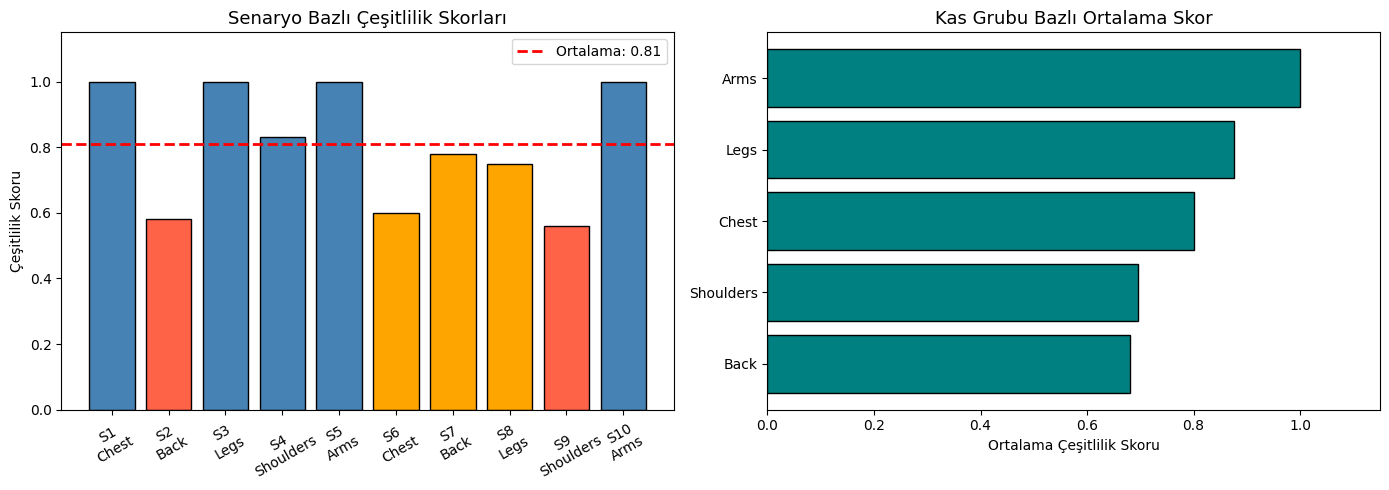

✅ Değerlendirme grafiği kaydedildi: degerlendirme_grafik.png


In [10]:
# Değerlendirme grafikleri
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Senaryo bazlı çeşitlilik skoru
renkler = ['steelblue' if s >= 0.8 else 'orange' if s >= 0.6 else 'tomato'
           for s in sonuc_df['Çeşitlilik Skoru']]
axes[0].bar(
    [f"{r['Senaryo']}\n{r['Kas Grubu']}" for _, r in sonuc_df.iterrows()],
    sonuc_df['Çeşitlilik Skoru'],
    color=renkler, edgecolor='black'
)
ort = sonuc_df['Çeşitlilik Skoru'].mean()
axes[0].axhline(y=ort, color='red', linestyle='--', linewidth=2,
                label=f'Ortalama: {ort:.2f}')
axes[0].set_title('Senaryo Bazlı Çeşitlilik Skorları', fontsize=13)
axes[0].set_ylabel('Çeşitlilik Skoru')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Sağ: Kas grubu bazlı ortalama skor
kg_ort = sonuc_df.groupby('Kas Grubu')['Çeşitlilik Skoru'].mean().sort_values()
axes[1].barh(kg_ort.index, kg_ort.values, color='teal', edgecolor='black')
axes[1].set_title('Kas Grubu Bazlı Ortalama Skor', fontsize=13)
axes[1].set_xlabel('Ortalama Çeşitlilik Skoru')
axes[1].set_xlim(0, 1.15)

plt.tight_layout()
plt.savefig('degerlendirme_grafik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Değerlendirme grafiği kaydedildi: degerlendirme_grafik.png")

---
## 9. Sonuç ve Çıkarımlar

- Sistem, seçilen kas grubuna göre TF-IDF tabanlı içerik filtresi ile çeşitli egzersizler önermektedir.
- Greedy Max Diversity algoritması sayesinde birbirine benzer hareketler yerine farklı açılardan çalışan hareketler tercih edilmektedir.
- Değerlendirme sonuçları programın ne kadar dengeli olduğunu sayısal olarak göstermektedir.

### Sınırlılıklar
- Kullanıcının fitness düzeyi ve sağlık durumu dikkate alınmamaktadır.
- Yalnızca tek kas grubu seçilebilmektedir.
- Egzersizler arası dinlenme süresi önerilmemektedir.

### Geliştirme Önerileri
- Beginner / Intermediate / Advanced seviye filtresi eklenebilir.
- Birden fazla kas grubu seçimi desteklenebilir.
- Streamlit ile interaktif web arayüzü eklenebilir.
- Egzersiz açıklama ve video bağlantıları eklenebilir.